In [319]:
# Existem valores ausentes ou inconsistentes no dataset? Se sim, escolha e justifique (em uma célula de texto) uma estratégia de tratamento.


In [320]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# Peguei o código da importação dos dados no Heart Disease Dataset

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


In [321]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.
Path to dataset files: /kaggle/input/heart-disease-dataset


In [322]:
df = pd.read_csv("/kaggle/input/heart-disease-dataset/heart.csv")

In [323]:
df.head(20)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [324]:
duplicados = df[df.duplicated]
print(duplicados)
# Tem 723 linhas duplicadas, olhei os comentários no Heart Disease Dataset e vi comentários sobre duplicações, então fiz a função para verificar


      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [325]:
# Para eliminar as duplicatas
df.drop_duplicates()
df = df.reset_index(drop=True)

In [326]:
ausentes = df.isna().sum()
print(ausentes)
# Obtive 0 resultados ausentes

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [327]:
# 2. Plote histogramas e boxplots das variáveis numéricas. Quais apresentam distribuição assimétrica ou outliers relevantes?

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

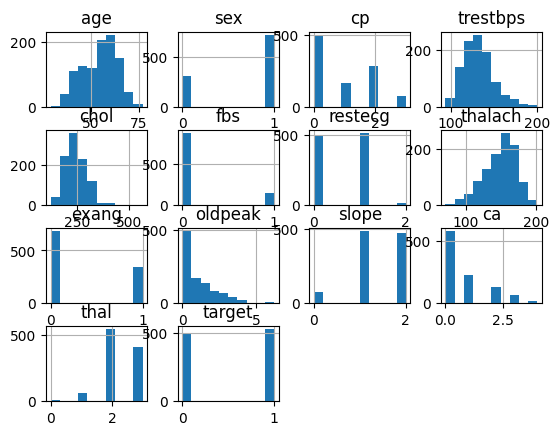

In [328]:
df.hist()


<Axes: >

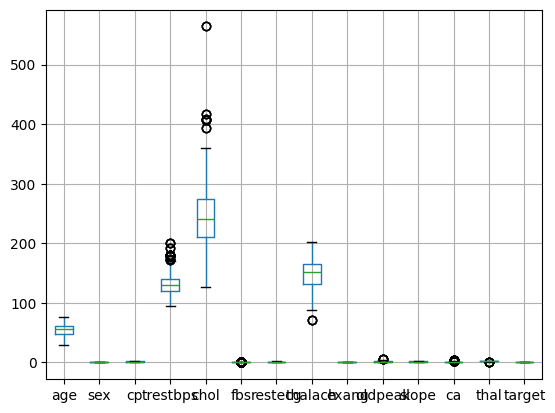

In [329]:
df.boxplot()
# Vejo que tem outliers em: trestbps, chol
# fbs, thalach, oldpeak, ca, thal




In [330]:
# 3.Construa uma matriz de correlação. Quais variáveis têm maior associação com o diagnóstico de doença cardíaca?

In [331]:
df.corr()
# Segundo a documentação, varia em 1 e -1
# A matriz diagonal 1.0000 é a correlata positiva
# aqui vou usar a IA pela primeira vez para interpretar a matriz.
# As variáveis mais fortes de correlação positiva: cp (0.43) → tipo de dor no peito, thalach (0.42) → frequência cardíaca máxima, slope (0.39) → inclinação do segmento S
# Correlação negativa: exang (-0.43) → angina induzida por exercício, oldpeak (-0.43) → depressão ST, ca (-0.38) → número de vasos, thal (-0.33) → defeito cardíaco
# sex (-0.27), age (-0.22)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.103240,-0.071966,0.271121,0.219823,0.121243,-0.132696,-0.390227,0.088163,0.208137,-0.169105,0.271551,0.072297,-0.229324
sex,-0.103240,1.000000,-0.041119,-0.078974,-0.198258,0.027200,-0.055117,-0.049365,0.139157,0.084687,-0.026666,0.111729,0.198424,-0.279501
cp,-0.071966,-0.041119,1.000000,0.038177,-0.081641,0.079294,0.043581,0.306839,-0.401513,-0.174733,0.131633,-0.176206,-0.163341,0.434854
trestbps,0.271121,-0.078974,0.038177,1.000000,0.127977,0.181767,-0.123794,-0.039264,0.061197,0.187434,-0.120445,0.104554,0.059276,-0.138772
chol,0.219823,-0.198258,-0.081641,0.127977,1.000000,0.026917,-0.147410,-0.021772,0.067382,0.064880,-0.014248,0.074259,0.100244,-0.099966
fbs,0.121243,0.027200,0.079294,0.181767,0.026917,1.000000,-0.104051,-0.008866,0.049261,0.010859,-0.061902,0.137156,-0.042177,-0.041164
restecg,-0.132696,-0.055117,0.043581,-0.123794,-0.147410,-0.104051,1.000000,0.048411,-0.065606,-0.050114,0.086086,-0.078072,-0.020504,0.134468
thalach,-0.390227,-0.049365,0.306839,-0.039264,-0.021772,-0.008866,0.048411,1.000000,-0.380281,-0.349796,0.395308,-0.207888,-0.098068,0.422895
exang,0.088163,0.139157,-0.401513,0.061197,0.067382,0.049261,-0.065606,-0.380281,1.000000,0.310844,-0.267335,0.107849,0.197201,-0.438029
oldpeak,0.208137,0.084687,-0.174733,0.187434,0.064880,0.010859,-0.050114,-0.349796,0.310844,1.000000,-0.575189,0.221816,0.202672,-0.438441


In [332]:
# 4. Compare a distribuição de colesterol e pressão arterial entre os grupos com e sem doença. Use testes estatísticos para validar as diferenças.

Text(0, 0.5, 'Frequência')

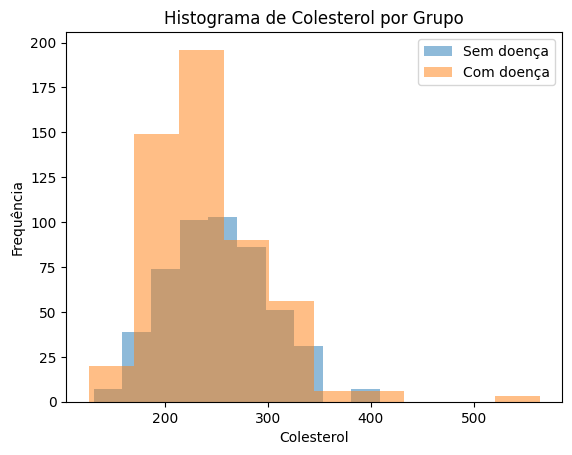

In [333]:
plt.hist(df[df['target']==0]['chol'], alpha=0.5, label='Sem doença')
plt.hist(df[df['target']==1]['chol'], alpha=0.5, label='Com doença')
plt.legend()

plt.title('Histograma de Colesterol por Grupo')
plt.xlabel('Colesterol')
plt.ylabel('Frequência')

# O grupo com doença a maioria está com o colesterol entre 150 e 250, entretanto, há pessoas com colesterol acima de 500 (seria um outlier?)
# O grupo sem doença tem a frequência menor e também mais frequente em colesterol entre 200 e 300. Há um outlier em 400.

Text(0, 0.5, 'Frequência')

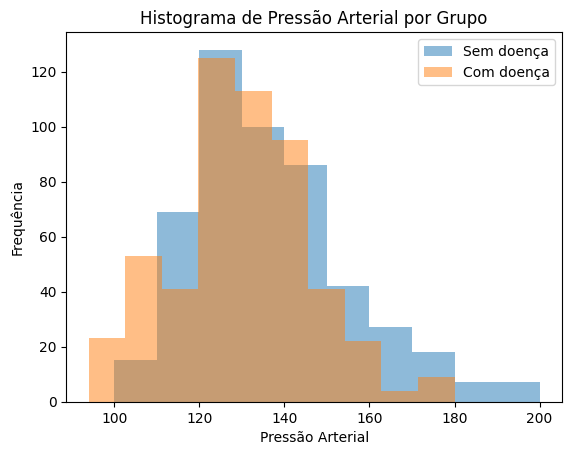

In [334]:
plt.hist(df[df['target']==0]['trestbps'], alpha=0.5, label='Sem doença')
plt.hist(df[df['target']==1]['trestbps'], alpha=0.5, label='Com doença')
plt.legend()
plt.title('Histograma de Pressão Arterial por Grupo')
plt.xlabel('Pressão Arterial')
plt.ylabel('Frequência')

# Há pessoas com pressão arterial abaixo de 100 e estão doentes, assim como há pessoas com pressão arterial acima de 180 e estão saudáveis.
# Entendi que a pressão arterial maior, está nos que não estão doentes, seria um sinal de saúde?

In [335]:
# 5. Treine um modelo de Random Forest. Avalie com acurácia, precisão, recall e F1-score. Justifique a escolha da métrica principal.

In [336]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Aqui eu decidi usar Scikit-Learn, fui para a documentação de RandomForest

feature_importances = ['thal', 'cp', 'oldpeak', 'ca', 'chol']
X = df[feature_importances]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

""" Obtive vários resultados número 1, então a taxa de acertos foi grande. Entretanto,
teve resultados que não chegaram a 100%, podendo ser falsos negativos, chutes.
O modelo está confiável.

IMPORTANTE!!! Defini as variáveis que considerei mais importantes e a precisão caiu bastante.
Estou interpretando com a IA o que isso significa.
Eu prefiro 100% em um modelo perfeito ou reasultado real? Aqui eu tive dúvidas.
Decidi incluir o colesterol como dados importante por conta do histograma que fiz
e aumentou bastante a precisão. Colesterol influência muito.

Eu escolhi o F1-score como métrica principal por me dar uma média entre precisão e recall, evitando
falsos negativos e falsos positivos, que na saúde isso pode ser a diferença da vida e a morte. Se o
contexto fosse outro, talvez eu não escolhesse essa métrica """



              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



' Obtive vários resultados número 1, então a taxa de acertos foi grande. Entretanto,\nteve resultados que não chegaram a 100%, podendo ser falsos negativos, chutes.\nO modelo está confiável.\n\nIMPORTANTE!!! Defini as variáveis que considerei mais importantes e a precisão caiu bastante.\nEstou interpretando com a IA o que isso significa.\nEu prefiro 100% em um modelo perfeito ou reasultado real? Aqui eu tive dúvidas.\nDecidi incluir o colesterol como dados importante por conta do histograma que fiz \ne aumentou bastante a precisão. Colesterol influência muito.\n\nEu escolhi o F1-score como métrica principal por me dar uma média entre precisão e recall, evitando\nfalsos negativos e falsos positivos, que na saúde isso pode ser a diferença da vida e a morte. Se o \ncontexto fosse outro, talvez eu não escolhesse essa métrica '

In [337]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [338]:
#Aplique feature engineering: crie faixas etárias, interações entre variáveis e normalize os dados. Como isso impacta o desempenho do modelo?


In [339]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Aqui eu fui pesquisar o que era feature engineering e vi que é padronizar os dados em valores como 0 ou 1, que eu consigo fazer
ages = [0, 12, 18, 25, 49, 59, 120]
label = ['crianca', 'adolescente', 'jovem', 'adulto', 'meia-idade', 'idoso']

df['age_group'] = pd.cut(df['age'], bins=ages, labels=label)

# df['colesterol_idosos'] = df['age_group_idoso'] * df['chol']
# df['colesterol_jovem'] = df['age_group_adolescente'] * df['chol']
# df['thal_sexo'] = df['sex'] * df['thal']

"""Durante essa etapa, meu f1-score diminiu, então tive que recalcular a rota, criei
colunas desnecessárias que atrapalham o meu modelo."""

df['thal_chol'] = df['thal'] * df['chol'] # esse melhora o desempenho
df['cp_oldpeak'] = df['cp'] * df['oldpeak'] # esse piora o desempenho
df['thal_trestbps'] = df['thal'] * df['trestbps'] # esse piora o desempenho
"""Com o colesterol, sempre melhora minha precisão."""

colunas_para_normalizar = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak','thal', 'sex', 'exang']
df[colunas_para_normalizar] = scaler.fit_transform(df[colunas_para_normalizar])

In [340]:
print(df.columns.tolist())

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'age_group', 'thal_chol', 'cp_oldpeak', 'thal_trestbps']


In [341]:
# Use um modelo de regressão logística e interprete os coeficientes. Quais variáveis aumentam ou reduzem o risco de doença?


In [346]:
# Comecei indo para a documentacão novamente e já vi a função
from sklearn.linear_model import LogisticRegression

X = df.select_dtypes(include=[np.number]).drop(columns=['target'], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = LogisticRegression()
clf.fit(X_train, y_train)

print(f"Acurácia: {clf.score(X_test, y_test):.2f}")

# Aqui foi com a IA
coef_df = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': clf.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])
print(coef_df[['Variável', 'Odds_Ratio']])

"""Parte importante aqui é que achei que chol fosse a variável mais importante
para o meu modelo, mas cp está em destaque"""


Acurácia: 0.79
         Variável  Odds_Ratio
2              cp    2.383973
7         thalach    1.803162
10          slope    1.679496
6         restecg    1.280032
15  thal_trestbps    0.998529
13      thal_chol    0.998516
14     cp_oldpeak    0.980187
5             fbs    0.942731
0             age    0.931830
4            chol    0.771128
3        trestbps    0.753711
12           thal    0.710920
8           exang    0.652993
9         oldpeak    0.449779
1             sex    0.438920
11             ca    0.431533


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


'Parte importante aqui é que achei que chol fosse a variável mais importante\npara o meu modelo, mas cp está em destaque'

In [ ]:
# Gere um gráfico de feature importance para explicar as predições do modelo. Quais variáveis mais influenciam o resultado?


/tmp/ipykernel_7387/2542353790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variável', data=coef_df, palette=colors)


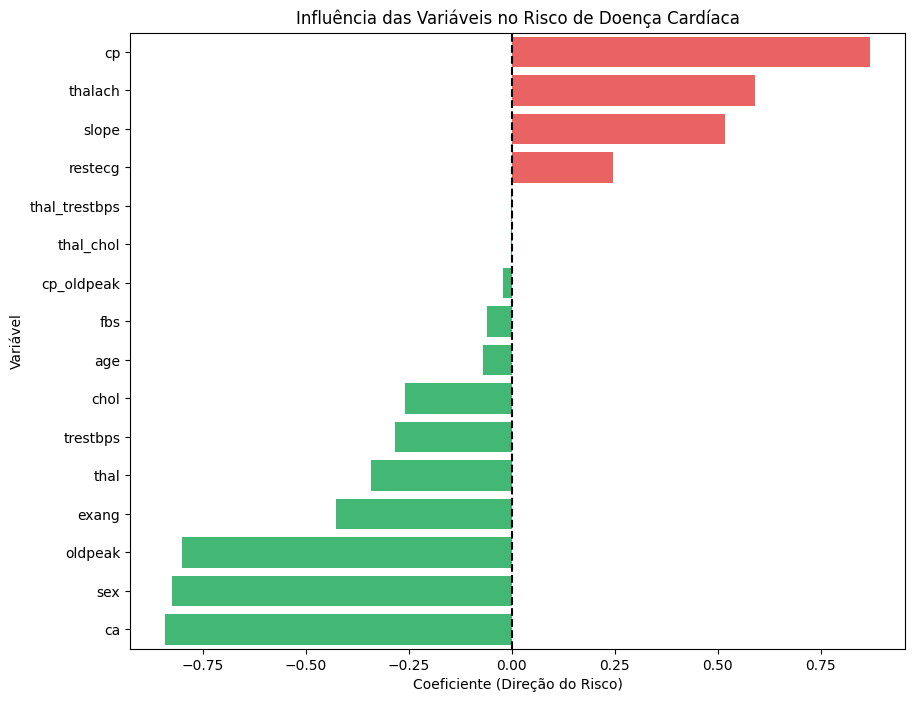

In [350]:
import seaborn as sns

plt.figure(figsize=(10, 8))
colors = ['#ff4d4d' if x > 0 else '#2ecc71' for x in coef_df['Coeficiente']]

sns.barplot(x='Coeficiente', y='Variável', data=coef_df, palette=colors)
plt.title('Influência das Variáveis no Risco de Doença Cardíaca')
plt.axvline(0, color='black', lw=1.5, linestyle='--')
plt.xlabel('Coeficiente (Direção do Risco)')
plt.show()



In [ ]:
# Compare o desempenho de pelo menos 3 algoritmos diferentes. Construa uma tabela comparativa e justifique qual você recomendaria para uso clínico.


In [352]:
# Comecei indo pegar a função do KNN na documentação e troquei as variáveis

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

"""A melhor previsão foi com RandowForest, a segunda com KNN e a terceira com LogisticRegression"""


              precision    recall  f1-score   support

           0       0.84      0.73      0.78       102
           1       0.76      0.86      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [356]:
modelos = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Regressão Logística": LogisticRegression()
}

resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    previsoes = modelo.predict(X_test)
    f1 = f1_score(y_test, previsoes)
    resultados.append({"Algoritmo": nome, "F1-Score": round(f1, 2)})

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

             Algoritmo  F1-Score
0        Random Forest      0.99
1                  KNN      0.81
2  Regressão Logística      0.80
